# Introduction to Cheminformatics with RDKit

In this notebook we explore how molecules can be represented, compared, and analyzed using RDKit.

We will move progressively from simple textual representations to full 3D structures:

- Representing molecules using SMILES
- Comparing molecules using fingerprints and similarity
- Generating 3D conformers
- Measuring structural differences (RMS, distance matrices)
- Reconstructing molecular graphs from XYZ coordinates

The goal is to understand how chemistry can be translated into:

- Graphs
- Mathematical descriptors
- Spatial geometry
- Computational workflows

By the end of this notebook, you should be comfortable moving between:

Text → Graph → 3D Geometry → Descriptors → Back to Chemistry


Let's start by importing the required libraries and setting up our environment.

In [1]:
# Core scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import itertools
import os

# Interactive visualization
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed
except:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, interactive, fixed

try:
    from IPython.display import display
except:
    !pip install IPython
    from IPython.display import display

# RDKit imports
try:
    from rdkit import Chem, RDConfig
    from rdkit.Chem import (
        Draw, rdmolops, AllChem, DataStructs, rdCIPLabeler, 
        rdMolAlign, rdDetermineBonds, rdFingerprintGenerator,
        Descriptors
    )
    from rdkit.Chem.Draw import rdMolDraw2D, IPythonConsole
except:
    !pip install rdkit # pip install --force-reinstall -v rdkit==2025.03.6
    from rdkit import Chem, RDConfig
    from rdkit.Chem import (
        Draw, rdmolops, AllChem, DataStructs, rdCIPLabeler, 
        rdMolAlign, rdDetermineBonds, rdFingerprintGenerator,
        Descriptors
    )
    from rdkit.Chem.Draw import rdMolDraw2D, IPythonConsole

# 3D visualization
try:
    import py3Dmol
except:
    !pip install py3Dmol
    import py3Dmol

In [2]:
# !pip install --force-reinstall -v rdkit==2025.03.6
print(f"RDKit version: {Chem.rdBase.rdkitVersion}")
assert Chem.rdBase.rdkitVersion >= '2025.03.6', "Please update your RDKit version to 2025.03.6 or later."

RDKit version: 2025.09.1


# Understanding SMILES Notation

SMILES (Simplified Molecular Input Line Entry System) is a line notation for describing the structure of chemical species using short ASCII strings. For example:
- `CCC` represents propane
- `C=C` represents ethene
- `c1ccccc1` represents benzene (aromatic)
- `CC(=O)O` represents acetic acid

It tells us:
- Which atoms are present
- How they are connected

It does NOT contain:
- 3D coordinates
- Explicit geometry

In RDKit, SMILES strings are converted into molecular graphs.

Below, we'll create an interactive widget that allows you to input SMILES strings and visualize the corresponding molecules in 2D.

In [3]:
# Widgets
smiles_input = widgets.Text(
    description="SMILES:",
    value="CCCC"
)

mol_image = widgets.Output()

def update_molecule(change):
    smiles = change["new"]
    mol = Chem.MolFromSmiles(smiles)
    
    mol_image.clear_output(wait=True)
    
    with mol_image:
        if mol is not None:
            display(Draw.MolToImage(mol))
        else:
            print("Invalid SMILES")

smiles_input.observe(update_molecule, names="value")
display(smiles_input)
display(mol_image)

Text(value='CCCC', description='SMILES:')

Output()

#### What is `Mol` in RDKit?

In RDKit, a `Mol` object is not just a "molecule" in the traditional chemical sense.

It is a **graph representation** of a molecule.

When we write:

```python
mol = Chem.MolFromSmiles("CCC")
```

we are creating a graph where:

- Atoms are nodes  
- Bonds are edges  

Internally, RDKit stores:

- 3 atoms  
- 2 bonds  
- Atom indices (0, 1, 2)  
- Bond types (single bonds)  
- Connectivity information (which atoms are connected)  

At this stage, the molecule contains:

- No 3D coordinates  
- No energy information  
- No conformers  

It is purely a connectivity graph.

Only after generating conformers does a `Mol` object contain 3D geometry.


In [4]:
# How to use rdkit molecule objects
smiles_1 = 'CCC' # SMILES string for propane
mol = Chem.MolFromSmiles(smiles_1)
print(mol)

# See attributes and methods
print(mol.__dir__())

['__module__', '__doc__', '__reduce__', '__instance_size__', '__init__', '__copy__', '__deepcopy__', 'GetNumAtoms', 'GetNumHeavyAtoms', 'GetAtomWithIdx', 'GetNumBonds', 'GetBondWithIdx', 'GetNumConformers', 'AddConformer', 'GetConformer', 'GetConformers', 'RemoveAllConformers', 'RemoveConformer', 'GetBondBetweenAtoms', 'HasQuery', 'HasSubstructMatch', 'GetSubstructMatch', 'GetSubstructMatches', 'SetProp', 'SetDoubleProp', 'SetIntProp', 'SetUnsignedProp', 'SetBoolProp', 'HasProp', 'GetProp', 'GetDoubleProp', 'GetIntProp', 'GetUnsignedProp', 'GetBoolProp', 'ClearProp', 'ClearComputedProps', 'UpdatePropertyCache', 'NeedsUpdatePropertyCache', 'ClearPropertyCache', 'GetStereoGroups', 'GetPropNames', 'GetPropsAsDict', 'GetAromaticAtoms', 'GetAtomsMatchingQuery', '__safe_for_unpickling__', '__getstate_manages_dict__', '__getinitargs__', '__getstate__', '__setstate__', 'Debug', 'ToBinary', 'GetRingInfo', 'GetAtoms', 'GetBonds', '_repr_png_', '_repr_svg_', '_repr_html_', '__GetSubstructMatch', 

In [5]:
# Iterate over atoms
atoms = mol.GetAtoms()
print(f"Atoms:", atoms)

for atom in atoms:
    print(f"\nAtom:", atom)
    
# See attributes and methods of an atom
print(f"\n", atom.__dir__())

Atoms: <rdkit.Chem._GetAtomsIterator object at 0x0000020E5BB2DF50>

Atom: <rdkit.Chem.rdchem.Atom object at 0x0000020E5BF08F20>

Atom: <rdkit.Chem.rdchem.Atom object at 0x0000020E5BF09000>

Atom: <rdkit.Chem.rdchem.Atom object at 0x0000020E5BF09070>

 ['__module__', '__doc__', '__reduce__', '__instance_size__', '__init__', '__copy__', 'GetAtomicNum', 'SetAtomicNum', 'GetSymbol', 'GetIdx', 'GetDegree', 'GetTotalDegree', 'GetTotalNumHs', 'GetNumImplicitHs', 'GetExplicitValence', 'GetImplicitValence', 'GetValence', 'GetTotalValence', 'HasValenceViolation', 'GetFormalCharge', 'SetFormalCharge', 'SetNoImplicit', 'GetNoImplicit', 'SetNumExplicitHs', 'GetNumExplicitHs', 'SetIsAromatic', 'GetIsAromatic', 'GetMass', 'SetIsotope', 'GetIsotope', 'SetNumRadicalElectrons', 'GetNumRadicalElectrons', 'GetQueryType', 'SetChiralTag', 'InvertChirality', 'GetChiralTag', 'SetHybridization', 'GetHybridization', 'HasOwningMol', 'GetOwningMol', 'GetNeighbors', 'GetBonds', 'Match', 'IsInRingSize', 'IsInRing',

In [6]:
# Loop over all atoms in the molecule
for atom in mol.GetAtoms():
    
    # Get the atom index (its position in the molecule)
    idx = atom.GetIdx()
    
    # Get the chemical symbol (C, O, N, etc.)
    symbol = atom.GetSymbol()
    
    # Get the degree (number of directly bonded atoms)
    degree = atom.GetDegree()
    
    # Print the information
    print(f"Atom {idx}: {symbol} (degree = {degree})")

Atom 0: C (degree = 1)
Atom 1: C (degree = 2)
Atom 2: C (degree = 1)


In [7]:
# Get the atom with index 1 from the molecule
atom = mol.GetAtomWithIdx(1)

# Print basic information about this atom
print(f"Atom {atom.GetIdx()}: {atom.GetSymbol()} (degree = {atom.GetDegree()})")

Atom 1: C (degree = 2)


In [8]:
# Loop over all atoms in the molecule
for atom in mol.GetAtoms():
    
    # Check whether the atom is part of any ring
    in_ring = atom.IsInRing() #atom.IsInRingSize(n) # True if the atom is in a ring of size n
    
    # Print the result in a readable way
    print(f"Atom {atom.GetIdx()} ({atom.GetSymbol()}) -> In ring: {in_ring}")

Atom 0 (C) -> In ring: False
Atom 1 (C) -> In ring: False
Atom 2 (C) -> In ring: False


Ring atom indices: [0, 1, 2, 3, 4, 5]


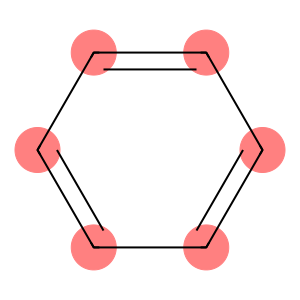

In [9]:
# Create a molecule (benzene)
smiles_ring = "c1ccccc1"
mol_ring = Chem.MolFromSmiles(smiles_ring)

# Identify atoms that are part of a ring
ring_atoms = []

for atom in mol_ring.GetAtoms():
    if atom.IsInRing():
        ring_atoms.append(atom.GetIdx())

print("Ring atom indices:", ring_atoms)

# Draw the molecule highlighting ring atoms
img = Draw.MolToImage(mol_ring, highlightAtoms=ring_atoms)
display(img)

In [10]:
# Loop directly over all bonds in the molecule
for bond in mol.GetBonds():
    
    # Get the indices of the bonded atoms
    begin_idx = bond.GetBeginAtomIdx()
    end_idx = bond.GetEndAtomIdx()
    
    # Get the atom symbols
    begin_symbol = mol.GetAtomWithIdx(begin_idx).GetSymbol()
    end_symbol = mol.GetAtomWithIdx(end_idx).GetSymbol()
    
    # Print bond information
    print(
        f"Bond: {begin_idx} ({begin_symbol}) "
        f"- {end_idx} ({end_symbol}) | "
        f"Type: {bond.GetBondType()}"
    )

Bond: 0 (C) - 1 (C) | Type: SINGLE
Bond: 1 (C) - 2 (C) | Type: SINGLE


**Different SMILES represent the same molecule**

A SMILES string is a textual traversal of a molecular graph. If you change the starting atom or the order in which bonds are traversed, the string changes.

**What is a canonical SMILES and why is it important?**

A canonical SMILES is a unique, deterministic SMILES generated by an algorithm that assigns a fixed ordering to the atoms of a molecule.

This guarantees that the same molecule will always produce the same SMILES string.

Canonical SMILES are important because they:
- Avoid duplicates in chemical databases  
- Allow reliable molecule comparison  
- Provide a consistent identifier for storage and indexing  


Canonical SMILES comparison:

CCO -> CCO
OCC -> CCO
C(O)C -> CCO


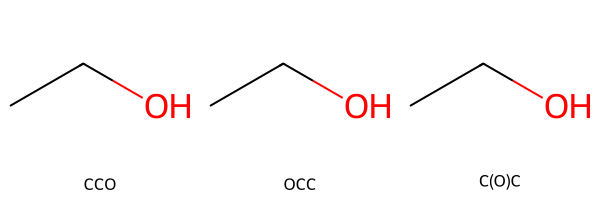

In [11]:
# Demonstrating that different SMILES represent the same molecular graph
smiles_list = ["CCO", "OCC", "C(O)C"]
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

print("\nCanonical SMILES comparison:\n")
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    canonical = Chem.MolToSmiles(mol, canonical=True)
    print(f"{smi} -> {canonical}")

# Display molecules side by side
Draw.MolsToGridImage(
    mols,
    legends=smiles_list,
    molsPerRow=3
)

## Exercises — Exploring `Mol` and Atom Objects

Create the following molecule:

```python
"CC(O)C=O"
```

Remember: a SMILES string is just text. How do we convert it into something RDKit can manipulate?

### Exercise 1 — Exploring the `Mol` Object

Use methods of the `Mol` object to answer the following:

1. How many atoms does the molecule have?
2. How many bonds does it have?
3. How many heavy atoms (non-hydrogen atoms)?
4. Does the molecule contain a ring?
5. What is the canonical SMILES of the molecule?

**Hints**

To explore what information a `Mol` object contains, inspect its available methods and attributes:

```python
print(dir(mol))
```

This will display all the methods you can use to access molecular (graph-level) properties.

In [12]:
# YOUR CODE HERE #

smiles = "CC(O)C=O"

# Create an RDKit molecule from this SMILES

### Exercise 2 — Looping Over Atoms

Loop over all atoms in the molecule and print the following information for each atom:

- Atom index
- Atom symbol
- Atomic number
- Degree (number of directly bonded atoms)
- Hybridization
- Formal charge

**Hints**

To explore what information an atom object contains, inspect its available methods and attributes:

```python
print(dir(atom))
```

This will display all the methods you can use to access atomic properties.

In [13]:
# YOUR CODE HERE #

# Molecular Descriptors and Properties

So far, we have explored molecular structure:
- Atoms  
- Bonds  
- Rings  
- Connectivity  

Now we move from structure to numbers.

A **molecular descriptor** is simply a numerical value calculated from a molecule. It converts chemical structure into quantitative information.

Descriptors allow us to:
- Compare molecules  
- Estimate properties  
- Build predictive models  

RDKit provides several types of descriptors:

- **Physical properties**  
  Examples: molecular weight, LogP (lipophilicity).

- **Topological descriptors**  
  Numbers derived from the molecular graph (connectivity and branching).

- **Connectivity indices**  
  Mathematical indices encoding how atoms are connected.

- **Count-based descriptors**  
  Simple counts such as number of atoms, bonds, rings, or heteroatoms.

These values transform molecular structure into features that can be analyzed computationally.

Let’s calculate some common descriptors and see what they tell us.

In [14]:
from rdkit.Chem import Descriptors

# Total number of available descriptors
num_descriptors = len(Descriptors._descList)
print(f"Total number of RDKit descriptors: {num_descriptors}\n")

# Show the first 10 descriptor names
print("First 10 descriptors:")
for name, _ in Descriptors._descList[:10]:
    print("-", name)

Total number of RDKit descriptors: 217

First 10 descriptors:
- MaxAbsEStateIndex
- MaxEStateIndex
- MinAbsEStateIndex
- MinEStateIndex
- qed
- SPS
- MolWt
- HeavyAtomMolWt
- ExactMolWt
- NumValenceElectrons


In [15]:
from rdkit.Chem import Descriptors

# Call the descriptor directly
direct_value = Descriptors.MolWt(mol)
print("MolWt (direct call):", direct_value)

MolWt (direct call): 46.069


Example - Lipinski’s Rule of Five is a set of empirical guidelines used to evaluate whether a molecule is likely to exhibit good oral bioavailability.

In [16]:
# SMILES string for propane
smiles = 'CCC' 
mol = Chem.MolFromSmiles(smiles)

# Molecular weight (average atomic masses, in g/mol)
MW = Descriptors.MolWt(mol)

# Number of nitrogen and oxygen atoms (NOT true H-bond acceptors)
HBA = Descriptors.NOCount(mol)

# Number of NH and OH groups (potential hydrogen bond donors)
HBD = Descriptors.NHOHCount(mol)

# Crippen LogP (estimated octanol/water partition coefficient, lipophilicity)
LogP = Descriptors.MolLogP(mol)


# Print descriptor values
print("Molecular Weight:", round(MW, 2))
print("HBA:", HBA)
print("HBD:", HBD)
print("LogP:", round(LogP, 2))
print()

# Apply Lipinski conditions
mw_ok = MW <= 500
hba_ok = HBA <= 10
hbd_ok = HBD <= 5
logp_ok = LogP <= 5

print("MW <= 500:", mw_ok)
print("HBA <= 10:", hba_ok)
print("HBD <= 5:", hbd_ok)
print("LogP <= 5:", logp_ok)
print()

# Final decision (at least 3 rules satisfied)
passed = (mw_ok + hba_ok + hbd_ok + logp_ok) >= 3
print("Passes Lipinski Rule of Five:", passed)

Molecular Weight: 44.1
HBA: 0
HBD: 0
LogP: 1.42

MW <= 500: True
HBA <= 10: True
HBD <= 5: True
LogP <= 5: True

Passes Lipinski Rule of Five: True


In [17]:
# Get the same descriptor from the internal list
name, func = Descriptors._descList[6]
list_value = func(mol)
print(f"{name} (from descriptor list):", list_value)

MolWt (from descriptor list): 44.096999999999994


In [18]:
def get_all_descriptors(mol, missing_value=None):
    """
    Calculate all available RDKit descriptors for a molecule.
    Returns a dictionary {descriptor_name: value}.
    """
    results = {}

    for name, func in Descriptors._descList:
        try:
            results[name] = func(mol)
        except Exception:
            results[name] = missing_value

    return results

In [19]:
# Compute all descriptors
all_descriptors = get_all_descriptors(mol)
print("Number of descriptors calculated:", len(all_descriptors))
print(all_descriptors)

Number of descriptors calculated: 217
{'MaxAbsEStateIndex': np.float64(2.125), 'MaxEStateIndex': np.float64(2.125), 'MinAbsEStateIndex': np.float64(1.25), 'MinEStateIndex': np.float64(1.25), 'qed': 0.3854706587740357, 'SPS': 6.0, 'MolWt': 44.096999999999994, 'HeavyAtomMolWt': 36.033, 'ExactMolWt': 44.062600255999996, 'NumValenceElectrons': 20, 'NumRadicalElectrons': 0, 'MaxPartialCharge': -0.059038363929048716, 'MinPartialCharge': -0.06564544121023959, 'MaxAbsPartialCharge': 0.06564544121023959, 'MinAbsPartialCharge': 0.059038363929048716, 'FpDensityMorgan1': 1.3333333333333333, 'FpDensityMorgan2': 1.3333333333333333, 'FpDensityMorgan3': 1.3333333333333333, 'BCUT2D_MWHI': 13.425713650761436, 'BCUT2D_MWLOW': 10.597286349238559, 'BCUT2D_CHGHI': 1.3523744386698806, 'BCUT2D_CHGLO': -1.4760582438091703, 'BCUT2D_LOGPHI': 1.5588136507614399, 'BCUT2D_LOGPLOW': -1.26961365076144, 'BCUT2D_MRHI': 3.9177136507614367, 'BCUT2D_MRLOW': 1.0892863492385598, 'AvgIpc': 0.9182958340544894, 'BalabanJ': np.



### Exercise — Exploring Available Descriptors

1. Choose any molecule of your interest.
2. Provide its SMILES representation.
3. Calculate LogP (`MolLogP`) value for your molecule.
4. Report the result a

In [20]:
# ============================
# YOUR CODE HERE
# ============================

# Create molecule from SMILES

# Calculate LogP (MolLogP) for the molecule

# Molecular Fingerprints and Similarity

So far, we transformed molecules into individual numerical descriptors.

Now we take a different approach.

A **molecular fingerprint** represents a molecule as a vector of bits (0s and 1s).
Each position in the vector encodes the presence or absence of specific structural features.

Fingerprints are widely used for:

- Similarity searches in large chemical databases  
- Virtual screening  
- Clustering molecules  
- Machine learning models  

RDKit supports several fingerprint types:

1. **Morgan (circular) fingerprints** – based on atom environments (ECFP-like)  
2. **Topological fingerprints** – based on paths in the molecular graph  
3. **MACCS keys** – predefined structural patterns  
4. **Atom Pair fingerprints** – based on atom pairs and distances  

Unlike single descriptors (which give one number), fingerprints encode many structural features at once.

Let’s generate some fingerprints and use them to measure molecular similarity.

In [21]:
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

# Create a Morgan fingerprint generator
# radius: how many bond steps around each atom are considered
#         (larger radius = larger atomic environment captured)
# fpSize: total length of the fingerprint (number of bits in the vector)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Generate fingerprint for the molecule
fingerprint = fpgen.GetFingerprint(mol)

print("Fingerprint type:", type(fingerprint))
print("\nNumber of bits:", fingerprint.GetNumBits())

# Convert to numpy array for visualization
fp_array = np.array(fingerprint)
print("\nFirst 20 bits:")
print(fp_array[:20])

Fingerprint type: <class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>

Number of bits: 2048

First 20 bits:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [22]:
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

# Create an RDKit (topological) fingerprint generator
# maxPath: maximum bond path length considered
# fpSize: total length of the fingerprint (number of bits)
fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=2, fpSize=1024)

# Generate fingerprint for the molecule
fingerprint = fpgen.GetFingerprint(mol)

print("Fingerprint type:", type(fingerprint))
print("\nNumber of bits:", fingerprint.GetNumBits())

# Convert to numpy array for visualization
fp_array = np.array(fingerprint)

print("\nFirst 20 bits:")
print(fp_array[:20])

Fingerprint type: <class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>

Number of bits: 1024

First 20 bits:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Morgan** 
- Morgan → circular environments  

**Topological** 
- RDKit FP → linear paths  

Which one is better?

It depends on the application.

- **Morgan fingerprints** are generally more robust for similarity searches 
  and machine learning tasks.
- **RDKit (topological) fingerprints** are simpler and sometimes easier 
  to interpret.

In modern practice, Morgan fingerprints are often the default choice.


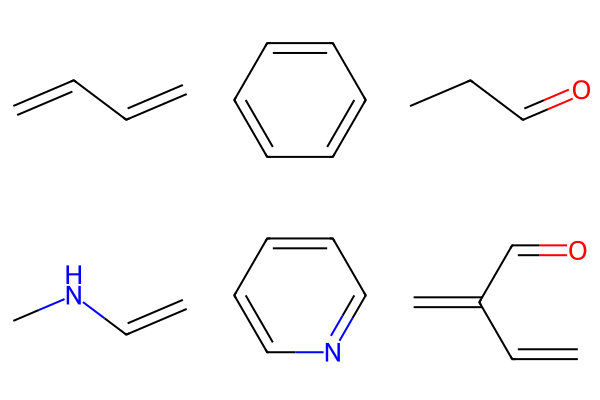

In [23]:
# List of SMILES strings
mol_smiles = [
    "C=CC=C",
    "c1ccccc1",
    "C(C=O)C",
    "CNC=C",
    "c1ncccc1",
    "C=C(C=O)C=C"
]

# Convert SMILES into RDKit molecule objects
mols = []

for smiles in mol_smiles:
    mol = Chem.MolFromSmiles(smiles)
    mols.append(mol)

# Display molecules in a grid
Draw.MolsToGridImage(mols)

### What Is the Most Similar Molecule?

Now, we can use these fingerprints to measure **molecular similarity**.

Similarity is typically measured using the **Tanimoto coefficient**, which ranges from:

- 0 → completely different  
- 1 → identical fingerprints  

Let’s find out:  
Which molecule is most similar to our old trusty mol?

Molecule 0
SMILES: C=CC=C
Similarity with propane: 0.25
----------------------------------------
Molecule 1
SMILES: c1ccccc1
Similarity with propane: 0.0
----------------------------------------
Molecule 2
SMILES: CCC=O
Similarity with propane: 0.5
----------------------------------------
Molecule 3
SMILES: C=CNC
Similarity with propane: 0.0
----------------------------------------
Molecule 4
SMILES: c1ccncc1
Similarity with propane: 0.0
----------------------------------------
Molecule 5
SMILES: C=CC(=C)C=O
Similarity with propane: 0.333
----------------------------------------


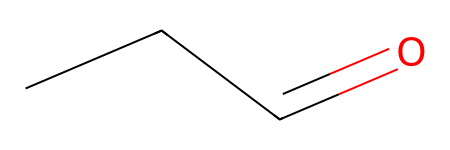

In [24]:
# Reference molecule (propane)
ref_mol = Chem.MolFromSmiles("CCC")
ref_fp = fpgen.GetFingerprint(ref_mol)

# Loop through all molecules
for i, mol in enumerate(mols):
    
    fp = fpgen.GetFingerprint(mol)
    similarity = DataStructs.TanimotoSimilarity(fp, ref_fp)
    
    smiles = Chem.MolToSmiles(mol)
    
    print("Molecule", i)
    print("SMILES:", smiles)
    print("Similarity with propane:", round(similarity, 3))
    print("-" * 40)

# Display molecule 2
display(mols[2])

## From SMILES to 3D Structures

So far, we have worked with **SMILES strings** to represent molecules and with **fingerprints** to compare them efficiently.

SMILES allow us to describe molecular connectivity (which atoms are bonded to which), and fingerprints allow us to measure similarity between molecules in a fast and compact way.

However, there is an important limitation:

SMILES and fingerprints describe molecules in **2D (topology only)**. They do not tell us how atoms are arranged in space.

In reality, molecules exist in **three dimensions**, and their 3D shape strongly influences:

- Reactivity  
- Molecular recognition  
- Docking interactions  
- Physical properties  
- Energy  

To work with realistic molecular geometries, we need to generate a **3D conformer**.

---

## Generating 3D Conformers in RDKit

The typical workflow to move from 2D to 3D is:

1. **Add hydrogens**  
   Geometry depends on all atoms, including hydrogens.

2. **Generate a 3D structure**  
   RDKit uses distance geometry to create a reasonable 3D arrangement of atoms.

3. **Optimize the geometry**  
   A force field (such as UFF or MMFF) adjusts the structure to reach a lower-energy conformation.

4. **Visualize the result**  
   We can then inspect the molecule in 3D.

In the following section, we will generate and visualize 3D conformers using RDKit.

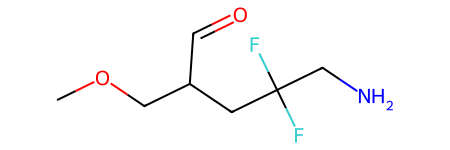

0

In [25]:
# Create molecule from SMILES
mol = Chem.MolFromSmiles("COCC(C=O)CC(F)(F)CN")

# Show 2D depiction (no 3D coordinates yet)
display(mol)

# Add hydrogens (important for 3D geometry)
mol = Chem.AddHs(mol)

# Generate 3D coordinates (create one conformer)
AllChem.EmbedMolecule(mol, AllChem.ETKDG())

# Optimize geometry using a force field
AllChem.UFFOptimizeMolecule(mol)

In [26]:
# Print atomic coordinates
conf = mol.GetConformer()
for atom in mol.GetAtoms():
    pos = conf.GetAtomPosition(atom.GetIdx())
    print(atom.GetSymbol(), pos.x, pos.y, pos.z)

C -3.3473317786676193 1.7667062485634588 0.6942173289104377
O -2.25994963037166 1.1714968751247679 0.022769614262037916
C -2.0777155427708562 -0.14641747323188342 0.4991453863241657
C -0.8594044482267599 -0.7833111323463287 -0.1917549604038658
C -0.789993736917293 -2.2472101585893767 0.16824748544579057
O -1.6050429708570046 -3.032055622906917 -0.290431222972631
C 0.4454222277789852 -0.045538625232878036 0.20145982369116167
C 1.6393073361763024 -0.386555518720788 -0.7142517242399758
F 1.9251604858840108 -1.7397649089674916 -0.6436732626267722
F 1.323692285514443 -0.06294667980689665 -2.024174742965871
C 2.8835512395867275 0.4045011647290755 -0.28760386582779374
N 4.026862681945108 0.05251990680864495 -1.1253435381145902
H -3.4867526955040713 2.7939299832524074 0.2993865652687301
H -4.2910370775082205 1.2057099155210578 0.5121674574572083
H -3.1486953263238266 1.850577795518755 1.7858426329673704
H -1.9105883025819708 -0.15328347048999424 1.6020868610124603
H -2.9813851079708327 -0.7573

In [27]:
# Create a 3D viewer
view = py3Dmol.view(width=500, height=400)

# Convert RDKit molecule (with 3D coordinates) to MolBlock format
mol_block = Chem.MolToMolBlock(mol)

# Add the molecule to the viewer
view.addModel(mol_block, 'sdf')

# Set visualization style (stick model)
view.setStyle({'stick': {}})

# Adjust camera to fit the molecule
view.zoomTo()

# Display
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [28]:
def genConf(m, nc=10, atomIds=[0]):
    """
    Generate multiple 3D conformers for a molecule,
    align them, and compute their energies.

    Parameters
    ----------
    m : RDKit Mol
        Molecule without hydrogens (SMILES-based).
    nc : int or "X"
        Number of conformers to generate.
        If "X", number is estimated from rotatable bonds.
    atomIds : list
        Atom indices used for alignment (e.g., a substructure core).

    Returns
    -------
    m : RDKit Mol
        Molecule containing multiple conformers.
    rmslist : list
        RMSD values after alignment.
    energies : list
        MMFF energies for each conformer.
    """

    # Count rotatable bonds (flexibility indicator)
    nr = int(AllChem.CalcNumRotatableBonds(m))

    # Add hydrogens (required for realistic 3D geometry)
    m = Chem.AddHs(m)

    # Assign stereochemistry from structure
    Chem.AssignAtomChiralTagsFromStructure(m, replaceExistingTags=True)

    # If nc = "X", estimate number of conformers automatically
    if nc == "X":
        if nr < 3:
            nc = 50
        else:
            nc = nr**3

    # Use ETKDGv3 for conformer generation
    params = AllChem.ETKDGv3()

    # Generate multiple conformers
    ids = AllChem.EmbedMultipleConfs(m, nc, params)

    # Align conformers and compute RMS differences
    rmslist = []
    AllChem.AlignMolConformers(m, RMSlist=rmslist, atomIds=atomIds)

    # Compute MMFF energies for each conformer
    energies = []
    for id in ids:
        prop = AllChem.MMFFGetMoleculeProperties(m, mmffVariant="MMFF94s")
        ff = AllChem.MMFFGetMoleculeForceField(m, prop, confId=id)
        ff.Minimize()
        en = float(ff.CalcEnergy())
        energies.append(en)

    return m, rmslist, energies

def visConfs(m):
    view = py3Dmol.view(width=500, height=400)
    view.removeAllModels()

    for conf in m.GetConformers():
        confId = conf.GetId()
        mol_block = Chem.MolToMolBlock(m, confId=confId)
        view.addModel(mol_block, 'sdf')

    view.setStyle({'stick': {}})
    view.zoomTo()
    view.show()

### Defining a Core Structure for Conformer Alignment

When generating multiple conformers, each conformation can be rotated and translated differently in space.  
Even though they represent the same molecule, their spatial orientation may differ.

If we compare two conformers without aligning them first, the RMSD would include differences that are not structural, but simply due to global orientation in space.

To compare conformers meaningfully, we align them using a common structural region — a **core substructure**.

This core serves as an anchor that allows us to:

- Identify a common structural fragment  
- Align conformers consistently  
- Compute RMSD values that reflect real geometric differences  

We first check that the core exists in the molecule, then extract the atom indices corresponding to the match.

These atom indices are used to align all conformers relative to the same reference region.

Core atom indices: [2, 3, 4, 5, 6]


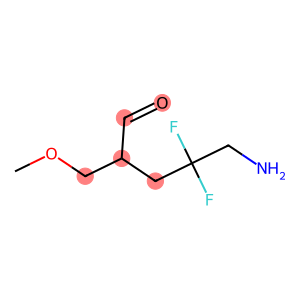

In [29]:
# Create molecule from SMILES
mol = Chem.MolFromSmiles("COCC(C=O)CC(F)(F)CN")

# Define a substructure pattern (core)
# This part will be used to align conformers later
core = Chem.MolFromSmiles("CC(C=O)C")

# Check that the core exists in the molecule
if not mol.HasSubstructMatch(core):
    raise ValueError("Core structure not found in molecule")

# Get atom indices corresponding to the core
atomIds = list(mol.GetSubstructMatch(core))

print("Core atom indices:", atomIds)

# Highlight the core atoms in the molecule
display(Draw.MolToImage(
    mol,
    highlightAtoms=atomIds
))

In [30]:
# Generate conformers, align them using the core, and compute energies
mol3d, rmslist, energies = genConf(mol, 10, atomIds=atomIds)

print("Number of conformers:", mol3d.GetNumConformers())
print("Energies:", energies)
print("RMS values:", rmslist)

# Select the conformer with the lowest energy
lowest_energy = min(energies)
lowest_energy_idx = energies.index(lowest_energy)

print("Lowest energy conformer index:", lowest_energy_idx)
print("Lowest energy value:", lowest_energy)
visConfs(mol3d)

Number of conformers: 10
Energies: [51.43932377180515, 45.79922529294083, 47.76007443482189, 46.19442052443626, 46.03037008217561, 45.32878128214545, 49.41935528740933, 48.90992144198498, 46.375980968939274, 51.37500106434442]
RMS values: [0.5325367157066067, 0.04406502779042817, 0.529692970995613, 0.5115318972296834, 0.5208285136582289, 0.5469388300335344, 0.5194286593291594, 0.4953576725091766, 0.5191438292602197]
Lowest energy conformer index: 5
Lowest energy value: 45.32878128214545


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [31]:
# Generate conformers, align them using the core, and compute energies
mol3d_no_allign, rmslist_no_allign, energies_no_allign = genConf(mol)

# Note: this will generate the same conformers as before, but without aligning them to the core.
print("Energies:", energies_no_allign)
print("RMS values:", rmslist_no_allign)

# Select the conformer with the lowest energy
lowest_energy = min(energies_no_allign)
lowest_energy_idx = energies_no_allign.index(lowest_energy)

print("Lowest energy conformer index:", lowest_energy_idx)
print("Lowest energy value:", lowest_energy)
visConfs(mol3d_no_allign)

Energies: [43.8273064525934, 44.36028694752864, 42.12374824979234, 48.504259455044114, 42.21368330791516, 49.270127862502456, 41.55949260040035, 46.66147125663849, 47.07008922918854, 52.31906012608176]
RMS values: [0.0, 0.0, 0.0, 4.2146848510894035e-08, 0.0, 0.0, 0.0, 0.0, 0.0]
Lowest energy conformer index: 6
Lowest energy value: 41.55949260040035


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [32]:
from ipywidgets import interact
import py3Dmol

def visConf(m, confId=0):
    view = py3Dmol.view(width=500, height=400)
    mol_block = Chem.MolToMolBlock(m, confId=confId)
    view.addModel(mol_block, 'sdf')
    view.setStyle({'stick': {}})
    view.zoomTo()
    return view.show()

interact(
    lambda confId: visConf(mol3d, confId),
    confId=(0, mol3d.GetNumConformers()-1)
)

interactive(children=(IntSlider(value=4, description='confId', max=9), Output()), _dom_classes=('widget-intera…

<function __main__.<lambda>(confId)>

## Exercise — Generate Conformers and Find the Lowest Energy

Use the function `genConf` to generate multiple 3D conformers for a molecule of your choice.

Task

1. Choose any molecule by writing its SMILES string.
2. Use `genConf` to generate conformers.
3. Print:
   - The number of conformers generated.
   - The lowest energy value.

**Hint**

For this exercise, you do **not** need to consider alignment or RMS values. Focus only on conformer generation and energy comparison.

In [33]:
# ==========================================
# YOUR CODE HERE — Generate Conformers
# ==========================================

# 1️⃣ Choose your molecule (write a SMILES string)

# 2️⃣ Generate conformers using genConf

# 3️⃣ Print number of conformers

# 4️⃣ Print the lowest energy value

## Working with XYZ Files

So far, we generated 3D coordinates directly inside RDKit. However, molecular geometries are often stored in external files.

One of the simplest formats for storing 3D coordinates is the **XYZ format**.

An XYZ file contains:

1. The number of atoms  
2. A comment line  
3. One line per atom: element symbol + x, y, z coordinates  

Unlike SMILES, XYZ files do **not** explicitly store connectivity. They only store atomic positions in space.

RDKit can:

- Read XYZ files
- Infer bonding based on interatomic distances
- Convert the structure to other formats (SMILES, MOL)
- Visualize the 3D geometry

Let’s explore how RDKit handles XYZ files.

In [34]:
from rdkit import Chem

def cleanup_xyz(filename):
    """
    Read an XYZ file and format it properly
    so it can be interpreted by RDKit.
    """

    # Read all lines
    lines = open(filename).readlines()

    # First line = number of atoms
    num_atoms = int(lines[0])

    # Ensure second line is a clean comment line
    lines[1] = "\n"

    # Keep only header + atomic coordinate lines
    lines = lines[:num_atoms + 2]

    # Reformat coordinate lines (remove extra spacing issues)
    for i in range(2, num_atoms + 2):
        parts = lines[i].split()
        lines[i] = "\t".join(parts) + "\n"

    xyz_block = "".join(lines)

    print("Cleaned XYZ block:\n")
    print(xyz_block)

    return xyz_block

# Clean the file
xyz_block = cleanup_xyz("data/example.xyz")

# Create RDKit molecule from XYZ
raw_mol = Chem.MolFromXYZBlock(xyz_block)

print("Number of atoms:", raw_mol.GetNumAtoms())
print("Number of bonds:", raw_mol.GetNumBonds())

Cleaned XYZ block:

14

C	2.142	1.395	-8.932
C	3.631	1.416	-8.537
C	4.203	-0.012	-8.612
C	5.691	0.009	-8.218
H	1.604	0.760	-8.260
H	1.745	2.388	-8.880
H	2.043	1.024	-9.930
H	4.169	2.051	-9.210
H	3.731	1.788	-7.539
H	3.665	-0.647	-7.940
H	4.104	-0.384	-9.610
H	6.088	-0.983	-8.270
H	5.791	0.381	-7.220
H	6.230	0.644	-8.890

Number of atoms: 14
Number of bonds: 0


In [35]:
import py3Dmol
from rdkit.Chem.Draw import IPythonConsole

def draw_with_spheres(mol):
    """
    Visualize a molecule in 3D using spheres and sticks.
    """

    view = py3Dmol.view(width=300, height=300)

    # Add RDKit molecule to the 3D viewer
    IPythonConsole.addMolToView(mol, view)

    # Set visualization style
    view.setStyle({
        'sphere': {'radius': 0.3},
        'stick': {'radius': 0.2}
    })

    view.zoomTo()
    view.show()


# Display the molecule
draw_with_spheres(raw_mol)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [36]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds

# Make a copy of the XYZ-based molecule
conn_mol = Chem.Mol(raw_mol)

# Infer connectivity based on 3D distances
rdDetermineBonds.DetermineConnectivity(conn_mol, charge=0)

print("Atoms:", conn_mol.GetNumAtoms())
print("Bonds:", conn_mol.GetNumBonds())

# Visualize molecule with inferred bonds
draw_with_spheres(conn_mol)

Atoms: 14
Bonds: 13


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

How do we save a molecule as an XYZ file? 

In [37]:
# Create molecule from SMILES
smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)

# Add hydrogens and generate 3D coordinates
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.UFFOptimizeMolecule(mol)

# Save as XYZ
xyz_block = Chem.MolToXYZBlock(mol)
with open("test.xyz", "w") as f:
    f.write(xyz_block)

print("XYZ file saved.")

XYZ file saved.


## Working with SDF Files

Unlike XYZ files, **SDF (Structure Data File)** format stores both:

- Atomic coordinates  
- Explicit connectivity (bonds)
- Optional molecular properties (metadata)

Because connectivity is explicitly stored, RDKit does **not** need to infer bonds from distances.

Let’s load an example SDF file and inspect its contents.

Number of atoms: 7
Number of bonds: 6


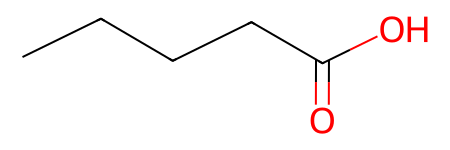

In [38]:
# Read SDF file
supplier = Chem.SDMolSupplier("data/sdf/example.sdf")

mol = supplier[0]

print("Number of atoms:", mol.GetNumAtoms())
print("Number of bonds:", mol.GetNumBonds())

# Show molecule
display(mol)

How do we save it as an SDF file?

In [39]:
# Create molecule
smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

# Generate 3D
AllChem.EmbedMolecule(mol, AllChem.ETKDG())
AllChem.UFFOptimizeMolecule(mol)

# Calculate descriptors
logp = Descriptors.MolLogP(mol)
mw = Descriptors.MolWt(mol)

# Store descriptors as properties in the molecule
mol.SetProp("LogP", str(logp))
mol.SetProp("MolecularWeight", str(mw))

# Write SDF file
writer = Chem.SDWriter("test.sdf")
writer.write(mol)
writer.close()
print("SDF file with descriptors saved.")

SDF file with descriptors saved.


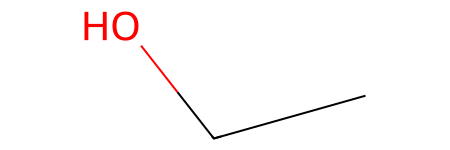

In [40]:
# Read SDF file
supplier = Chem.SDMolSupplier("test.sdf")
mol = supplier[0]

# Show molecule
display(mol)

## Working with CSV Files

Unlike SDF files, a **CSV (Comma-Separated Values)** file does not store molecular structures directly.

Instead, it typically stores:

- SMILES strings (text representation of molecules)
- Molecular identifiers (names, codes)
- Calculated descriptors or other properties

A CSV file does **not** contain:
- 3D coordinates
- Explicit bond information

To work with molecules stored in a CSV file, we must:

1. Read the file as a table
2. Extract the SMILES column
3. Convert each SMILES string into an RDKit molecule object

Let’s load an example CSV file and inspect its contents.

In [41]:
# Read CSV file
df = pd.read_csv("data/molecules.csv")
print("CSV content:")
print(df)

# Convert SMILES column to RDKit molecules
molecules = []
for smiles in df["SMILES"]:
    mol = Chem.MolFromSmiles(smiles)
    molecules.append(mol)

print(f"\nNumber of molecules created: {len(molecules)}\n")
print(f"Molecules {molecules}")

CSV content:
     code_name    SMILES
0      ethanol       CCO
1      benzene  c1ccccc1
2  acetic_acid   CC(=O)O

Number of molecules created: 3

Molecules [<rdkit.Chem.rdchem.Mol object at 0x0000020E5BFABF40>, <rdkit.Chem.rdchem.Mol object at 0x0000020E5BFAB6F0>, <rdkit.Chem.rdchem.Mol object at 0x0000020E5BFFC040>]


How do we save it as an CSV file?

In [42]:
# Empty list to store data for the new CSV
data = []

# Using molecules list created from the CSV file used before
for smiles in df["SMILES"]:
    mol = Chem.MolFromSmiles(smiles)
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    
    data.append({
        "SMILES": smiles,
        "MolecularWeight": mw,
        "LogP": logp
    })

# Create DataFrame
df_out = pd.DataFrame(data)

# Save to CSV
df_out.to_csv("test.csv", index=False)

print("CSV file saved.")

CSV file saved.


------------------------------
## 🔎 Solutions

This section contains the suggested solutions for all exercises in the notebook.

Try to complete the exercises on your own before reviewing the answers. The goal is not only to obtain the correct output, but to understand the underlying concepts.

------------------------------

In [43]:
# ================================
# SOLUTIONS — Block: Mol & Atoms
# ================================

from rdkit import Chem

# ----------------
# Exercise 1 — Mol object
# ----------------

mol = Chem.MolFromSmiles("CC(O)C=O")

print("Number of atoms:", mol.GetNumAtoms())
print("Number of bonds:", mol.GetNumBonds())
print("Number of heavy atoms:", mol.GetNumHeavyAtoms())
print("Number of rings:", mol.GetRingInfo().NumRings())
print("Canonical SMILES:", Chem.MolToSmiles(mol, canonical=True))

print("\n" + "="*50 + "\n")

# ----------------
# Exercise 2 — Loop over atoms
# ----------------

for atom in mol.GetAtoms():
    print(f"Atom index: {atom.GetIdx()}")
    print(f"Symbol: {atom.GetSymbol()}")
    print(f"Atomic number: {atom.GetAtomicNum()}")
    print(f"Degree: {atom.GetDegree()}")
    print(f"Hybridization: {atom.GetHybridization()}")
    print(f"Formal charge: {atom.GetFormalCharge()}")
    print("-" * 40)

Number of atoms: 5
Number of bonds: 4
Number of heavy atoms: 5
Number of rings: 0
Canonical SMILES: CC(O)C=O


Atom index: 0
Symbol: C
Atomic number: 6
Degree: 1
Hybridization: SP3
Formal charge: 0
----------------------------------------
Atom index: 1
Symbol: C
Atomic number: 6
Degree: 3
Hybridization: SP3
Formal charge: 0
----------------------------------------
Atom index: 2
Symbol: O
Atomic number: 8
Degree: 1
Hybridization: SP3
Formal charge: 0
----------------------------------------
Atom index: 3
Symbol: C
Atomic number: 6
Degree: 2
Hybridization: SP2
Formal charge: 0
----------------------------------------
Atom index: 4
Symbol: O
Atomic number: 8
Degree: 1
Hybridization: SP2
Formal charge: 0
----------------------------------------


In [44]:
# ==========================================
# SOLUTIONS — Block: Molecular Descriptors
# ==========================================

from rdkit import Chem
from rdkit.Chem import Descriptors

# ----------------
# Exercise 1 — Calculate LogP
# ----------------

mol = Chem.MolFromSmiles("CC(O)C=O")

logp = Descriptors.MolLogP(mol)

print("LogP (MolLogP):", round(logp, 3))

LogP (MolLogP): -0.434


In [45]:
# ==========================================
# SOLUTION — Generate Conformers
# ==========================================

from rdkit import Chem

# Example molecule (students could choose any)
smiles = "CCO"
mol = Chem.MolFromSmiles(smiles)

# Generate conformers
mol_1_3d, rmslist, energies = genConf(mol)

# Print number of conformers
print("Number of conformers:", mol_1_3d.GetNumConformers())

# Find and print lowest energy
lowest_energy = min(energies)
print(energies)
print("Lowest energy value:", lowest_energy)

Number of conformers: 10
[-1.3368570594508804, -1.5170975764249588, -1.336857063203523, -1.3368570618611888, -1.3368570639858062, -1.3368570639641364, -1.3368570633161245, -1.3368570632219454, -1.3368570632144423, -1.3368570632102559]
Lowest energy value: -1.5170975764249588
